# Template for multi-pitch detection TP

*(reference: Klapuri) but with pitch detection with spectral sum

*From G. Richard (with help from P. Vernhet), MAJ: 2025*

**python version : 3.6**

In [1]:
import os, sys, wave, struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from math import ceil, floor
from IPython.display import display, Audio

Functions

In [2]:
def load_music(file):
    return wave.open(file, 'rb')


def play_music(music, rate):
    display(Audio(music, rate=rate))


def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()


def nextpow2(x):
    assert x>0
    p = ceil(np.log2(x))
    x_ = 2**p
    assert 2**(p-1) < x <= x_
    return p, x_


def f2idx(F, df):
    """
    Convert frequency to corresponding index in "frequencies" array
    """
    return ceil(F/df)

## 0 - Reading and playing .wav file

Choose the name of music for the rest of the notebook. Sounds are assumed to be set in a folder named 'sons_mutltipitch' (same directory as notebook).

In [3]:
current_path = os.getcwd()
data_path = os.path.join(current_path, 'sons_multipitch')
filename = 'A4_piano.wav'
music = os.path.join(data_path, filename)

### **Using wave**

In [4]:
wavefile = load_music(music)
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=32000, nframes=31994, comptype='NONE', compname='not compressed')


In [5]:
play = True
if play :
    play_music(music, rate=int(wavefile.getframerate()))

In [6]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [7]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

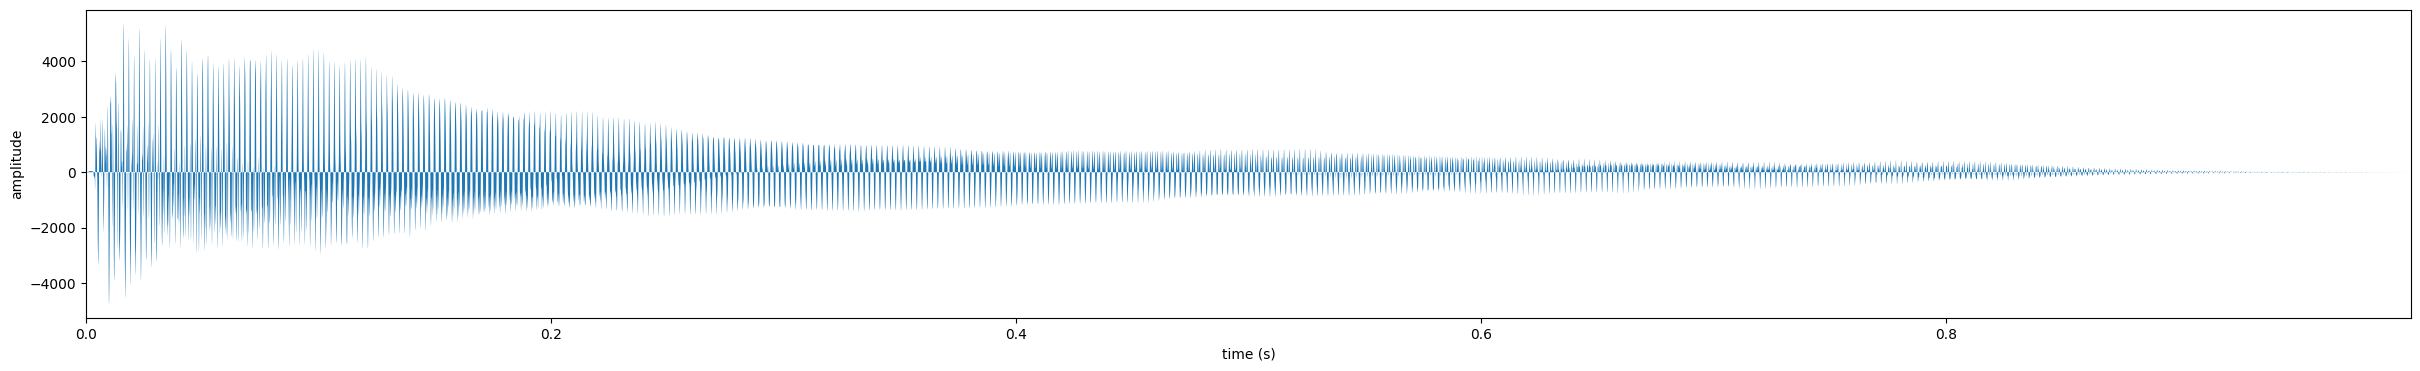

In [8]:
plot_sound(x, times)

## I - Window and Fast Fourier Transform

### Answers competed

**1. Window size :** A Hamming window is used, its length covering $700$ ms of the entire signal. It means we have $0.7*32000= 22400$ samples. This relatively long window provides good frequency resolution, which helps separate close spectral peaks and detect and harmonics reliably. The trade-off is poorer time resolution, but we do not need a time precision for this note-detection task (quasi-stationnary signal).


**2. Offset :** The offset is chosen to be about $100$ ms, so we will be able to discard the attack of the sound. This allows the analysis to focus on a quasi-stationary part of the signal, which leads to more reliable frequency estimation.

**3. Spectral precision after the FFT :** The frequency precision is given by $dF_{\text{min}}=\frac{F_{s}}{Nfft}$, where $Nfft$ is the size of the FFT window. => 1.43 Hz


In [9]:
N=ceil(0.7*Fs)       # Window size of analysed signal (only one window of signal is analysed)
dF_min=Fs/N   # Minimal frequency resolution
print('The minimal frequency resolution is of {:.2f} Hz'.format(dF_min))

The minimal frequency resolution is of 1.43 Hz


In [10]:
w=np.hamming(N)  # Window
width = 4*dF_min # largeur du pic spectral (en Hz) 4*dF_min
eps=float(1e-20)   #precision

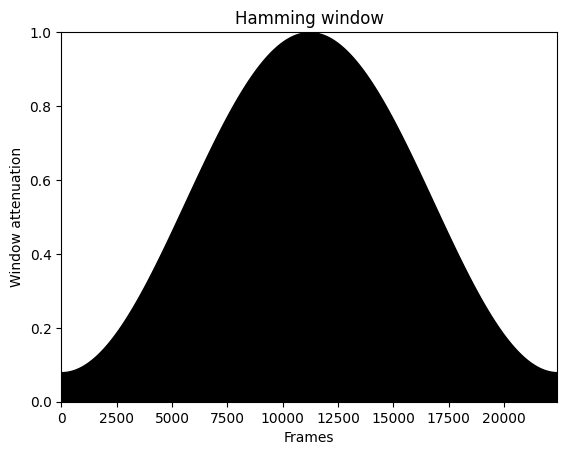

In [11]:
plt.fill_between(np.arange(len(w)), w, color='k')
plt.title('Hamming window')
plt.xlabel('Frames')
plt.ylabel('Window attenuation')
plt.xlim(0, len(w))
plt.ylim(0, 1)
plt.show()

### Discarding the attack of the sound

In [12]:
offset=ceil(0.1*Fs)
xw=x[offset:offset+N]*w   # xw is the analysed signal frame
n_xw = xw.size

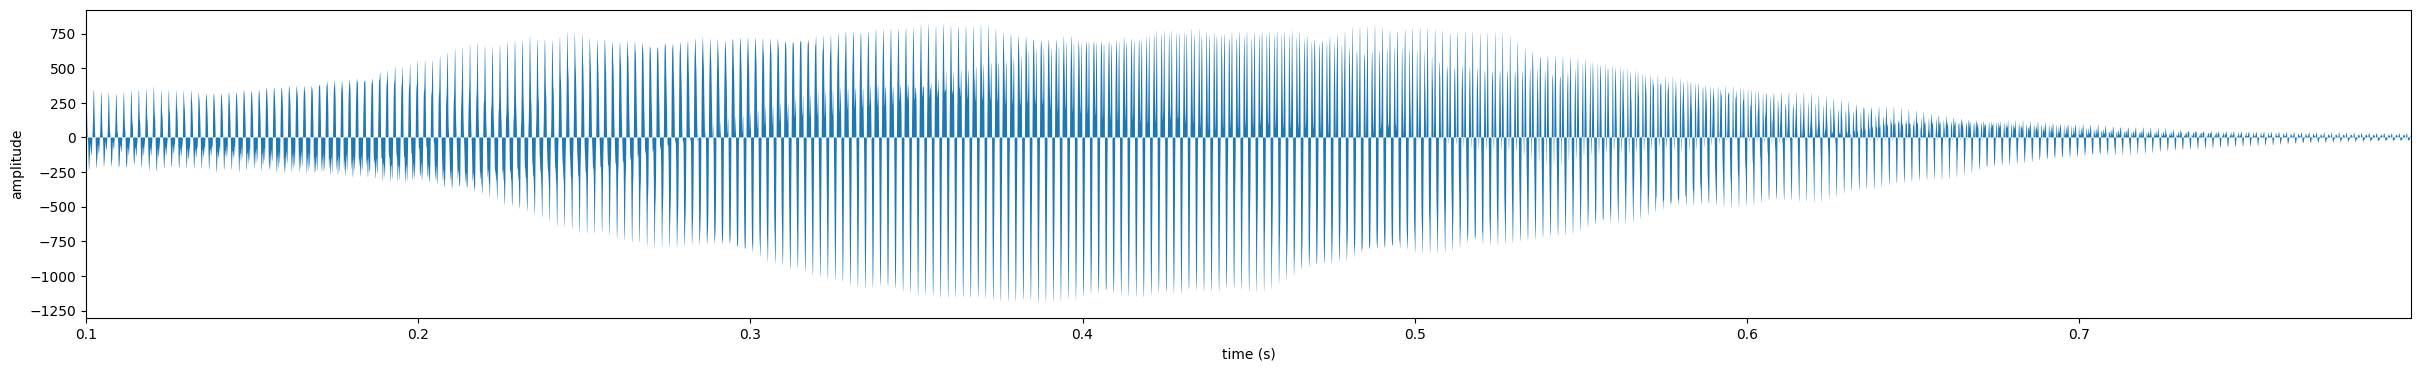

In [13]:
plot_sound(xw, times[offset:offset+N])

This is the temporal visualization of the sound we will be working on.

### Processing for efficient FFT (*by truncating to powers of 2*)

In [14]:
#Minimal number of data points to satisfy the minimal frequency resolution
Nfft_min=Fs/dF_min

#compute the smallest power of two that satisfies the minimal frequency resolution for FFT
p, Nfft = nextpow2(Nfft_min)
x_fft = np.fft.fft(xw, n=Nfft) #calcul FFT
x_fft /= np.max(np.abs(x_fft))+eps # Normalization

df=Fs/Nfft # frequency virtual resolution of FFT
print('Frequency virtual resolution of FFT {:.2} Hz'.format(df))

Frequency virtual resolution of FFT 0.98 Hz


In [15]:
frequencies = np.arange(Nfft)*df  # equivalent to np.fft.fftfreq(n=Nfft, d=timestep)
X_fft = np.abs(x_fft) # absolute value of FFT (phase doesn't play a role)

Plot FFT spectrum

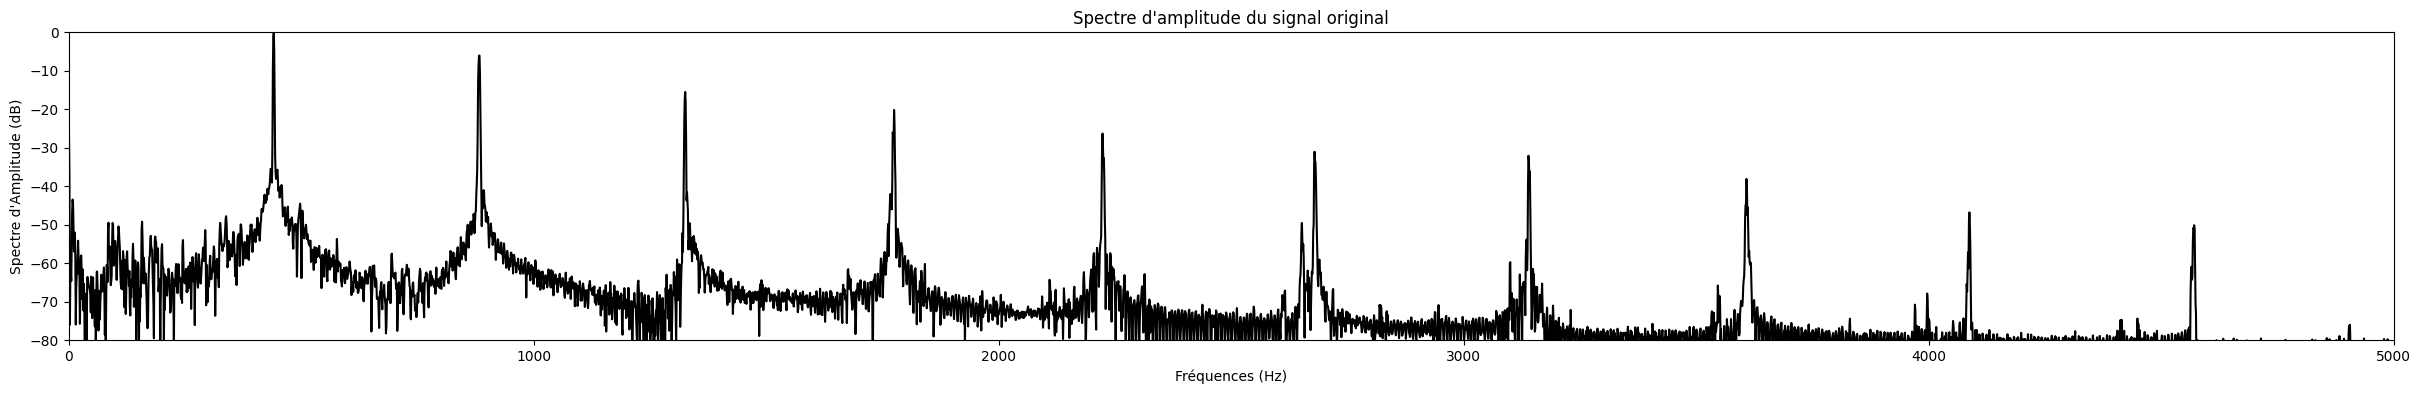

In [16]:
plt.figure(figsize=(30, 4))
plt.plot(frequencies[:int(Nfft/2)], 20*np.log10(X_fft[:int(Nfft/2)]), color='k')
plt.xlim(0, 5000)
plt.ylim(-80, 0)
plt.xlabel('Fréquences (Hz)')
plt.ylabel('Spectre d\'Amplitude (dB)')
plt.title('Spectre d\'amplitude du signal original')
plt.show()

For **A4_piano.wav**, we clearly see the harmonic around $\sim 440$ Hz and partials (multiples of the fundamental frequency peak).

## II - Fundamental frequency estimation by spectral product/sum method

The different steps include :

#loop on the number of pitches
    - example criterion could use an energy ratio "while criterion > seuil_F0"
    
  #Detection of main F0
  
        -Compute spectral sum
        -locate maximum
        -store value of estimated F0

  #Subtraction of main note (Main F0 with its harmonics)
        
        -localisation of harmonics around theoretical values (with or without inharmonicy coefficient)
        - beta: harmonicity coefficient ;  alpha: coefficient of tolerance
                
        - Harmonic suppression (wideness of an harmonic to be suppressed depends on the main lob of the TF of the analysis window); suppression of harmonics is done on abs(Xk) on forcing all values of a harmonic peak to the minimum value of the peak (e.g. the level of noise).
         
#end of loop

### Answers completed
The maximum frequency that can be used is $H\times df \times R = H \times R \times F_s/Nfft$

We need to have $H\times R\times df<=Fs/2$. We have then $R \times df<= Fs/2H$. Finally, we compute the maximum R value: $R<=Nfft/2H$ (because $df = Fs/Nfft$)

In [17]:
Fmin=100             # Minimal F0 frequency that can be detected
Fmax=900             # Maximal F0 frequency that can be detected
H=4                  # H = nombre de versions compressées
Rmax = floor(Nfft/(2*H)) # fréquence maximale

In [18]:
Nmin = f2idx(Fmin,df)-1
Nmax = f2idx(Fmax,df)
assert Nmax <= Rmax and Nmin >= 0
print(Nmin, Nmax)

102 922


Functions sum and product

In [19]:
def spectral_prod(x, R, H):
    """
    Spectral Product
    """
        
    X_fft = x[:R]
    max_bin = len(X_fft)//H
    prodd = np.ones(max_bin)
    
    for n in range(1,H+1):
        prod = compute_term_ss(X_fft,n)
        prodd*=prod[:max_bin]
    return prodd

def compute_term_ss(x,n):
    term = x[::n]
    return np.abs(term)

def spectral_sum(x, R, H):
    """
    Spectral sum
    """
    
    X_fft = x[:R]
    max_bin = len(X_fft)//H
    summ = np.zeros(max_bin)
    
    for n in range(1,H+1):
        prod = compute_term_ss(X_fft,n)
        summ+=prod[:max_bin]
    return summ


def spectral_method(x, R, H, method='product'):
    """
    Factorization of previous methods
    """
    assert method in ['sum', 'product']
    if method == 'sum':
        return spectral_sum(x, R, H)
    else:
        return spectral_prod(x, R, H)

We restrict the search of the fundamental frequency to the interval $[ F_{min}, F_{max} ]$ by converting these bounds into FFT-bin indices:

$$ N_{min}  = \frac{F_{min}}{df} $$

$$ N_{max}  = \frac{F_{max}}{df} $$

ensuring $N_{max}<= R$ so that all harmonics up to order H remain below Nyquist.

The spectral sum is computed over this range, and the fundamental frequency is estimated as the frequency bin with the maximum amplitude in the spectral sum:


In [20]:
method = 'sum'
P = spectral_method(X_fft, Rmax, H, method)

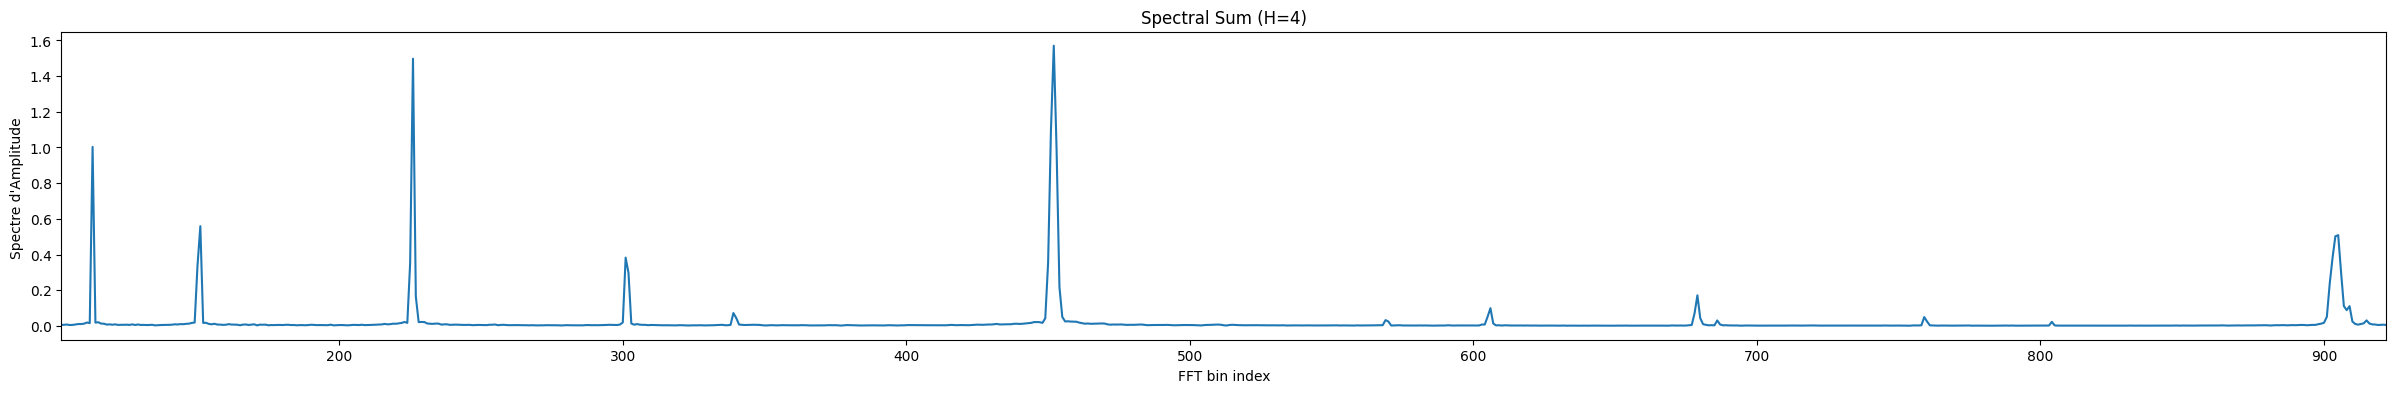

In [21]:
# with bins
plt.figure(figsize=(30, 4))
plt.plot(P)
plt.xlim(Nmin, Nmax)
plt.xlabel('FFT bin index')
plt.ylabel('Spectre d\'Amplitude ')
plt.title(f'Spectral Sum (H={H})')
plt.show()

Finding the maximum: 

In [22]:
fond_freq_N = np.argmax(P[Nmin:Nmax]) + Nmin
print(fond_freq_N)

452


In [23]:
fond_freq = fond_freq_N * df
fond_freq

np.float64(441.40625)

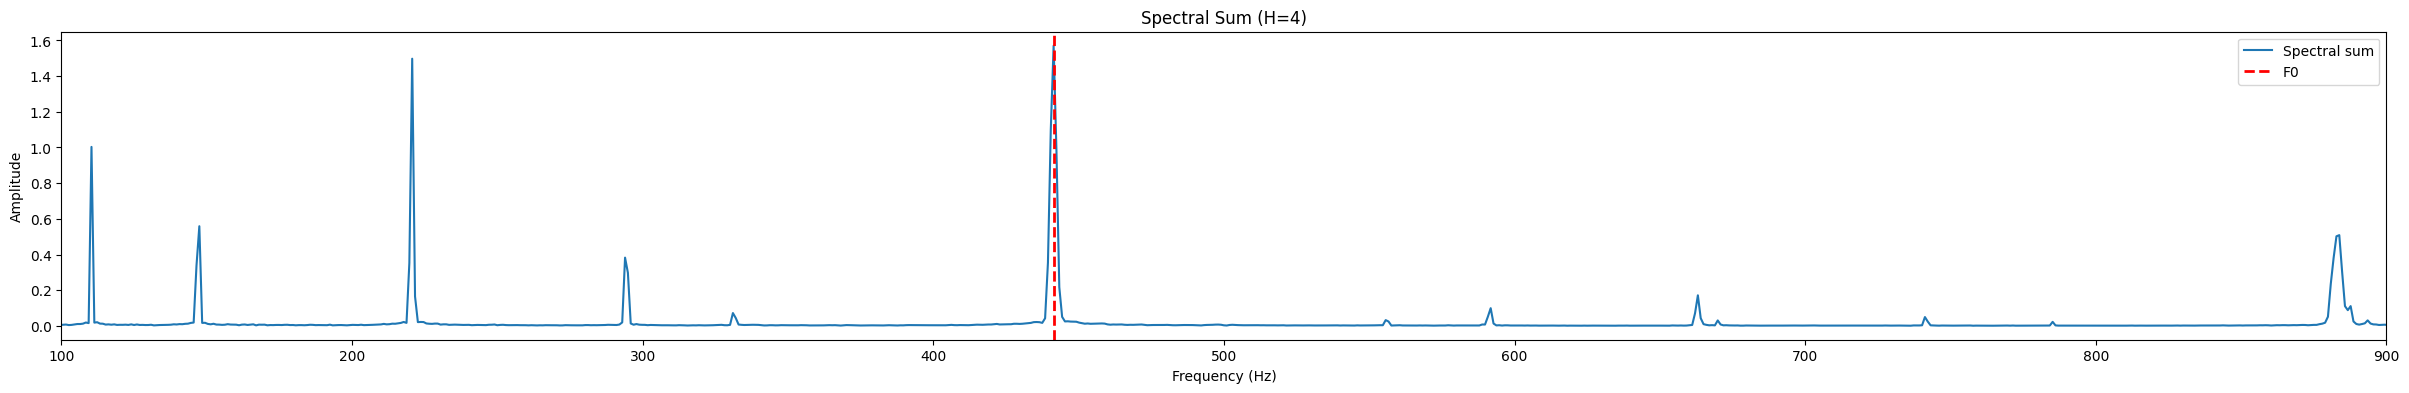

In [24]:
# in frequency domain
freq_P = np.arange(len(P)) * df  # Hz

plt.figure(figsize=(30, 4))
plt.plot(freq_P, P, label="Spectral sum")
plt.xlim(Fmin, Fmax)  #  Hz
plt.axvline(fond_freq, linestyle='--', linewidth=2, color= 'red', label="F0")
plt.xlabel('Frequency (Hz)')
plt.ylabel("Amplitude")
plt.legend()
plt.title(f"Spectral Sum (H={H})")
plt.show()



Let's remove the fondamental frequency

0.011149943148003383
Fundamental suppression: f0 = 441.41 Hz, peak bin=452, peak freq = 441.41 Hz
Suppressed bins: [447, 457] ie freq [436.52, 446.29] Hz


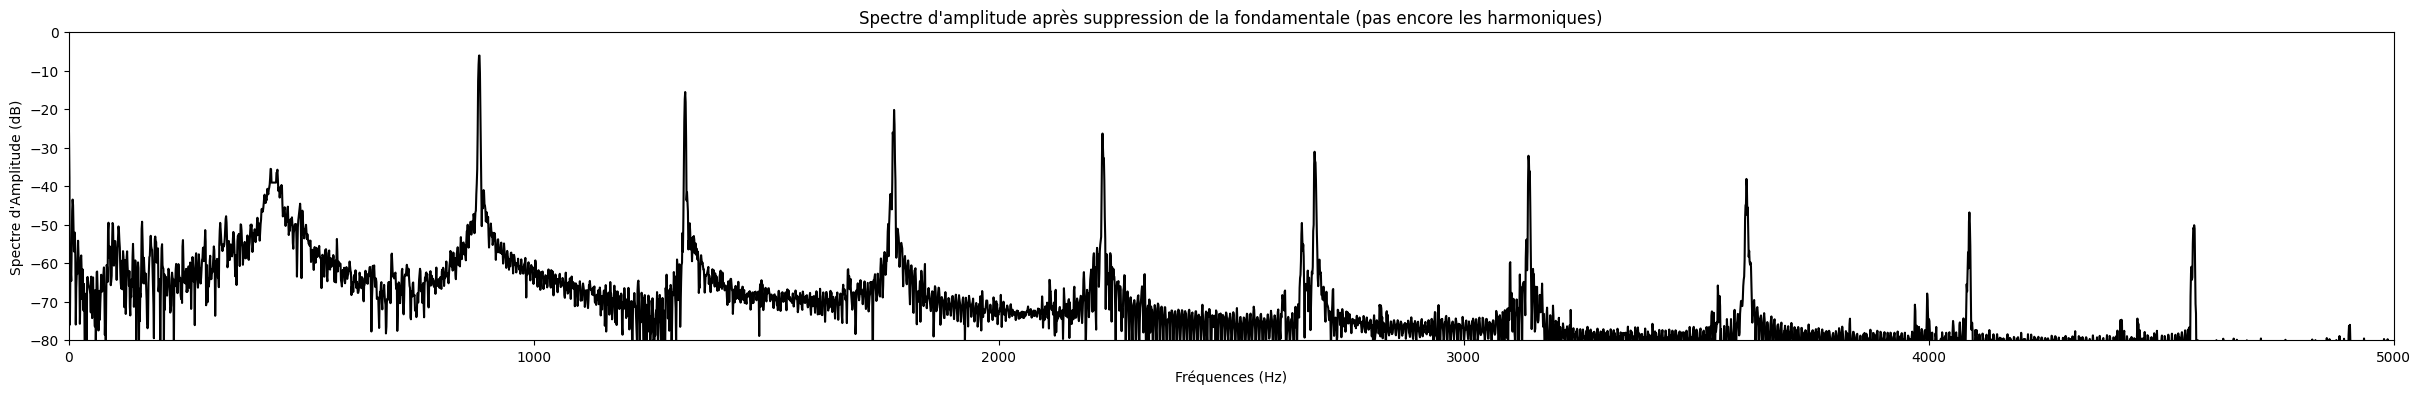

In [25]:
#Copy
X_res = X_fft.copy()
half = int(Nfft/2)

# The peak near the fundamental 
# largeur du pic spectral (en Hz) 4*dF_min
delta = 2 * df  # search half-width 
fmin = fond_freq - delta
fmax = fond_freq + delta

i1 = int(fmin // df)
i2 = int(fmax // df)

i_peak = np.argmax(X_res[i1:i2+1]) + i1

# Suppress around the peak 
w_bins = int(width // df)  # width is in Hz
j1 = i_peak - w_bins
j2 = i_peak + w_bins

noise = np.min(X_res[j1:j2+1])  # background noise
X_res[j1:j2+1] = noise
print(noise)

print(f"Fundamental suppression: f0 = {fond_freq:.2f} Hz, peak bin={i_peak}, peak freq = {i_peak*df:.2f} Hz")
print(f"Suppressed bins: [{j1}, {j2}] ie freq [{j1*df:.2f}, {j2*df:.2f}] Hz")

# Plot updated spectrum
plt.figure(figsize=(30, 4))
plt.plot(frequencies[:half], 20*np.log10(X_res[:half]), color='k') 
plt.xlim(0, 5000)
plt.ylim(-80, 0)
plt.xlabel('Fréquences (Hz)')
plt.ylabel("Spectre d'Amplitude (dB)")
plt.title("Spectre d'amplitude après suppression de la fondamentale (pas encore les harmoniques)")
plt.show()


| Signal file  | Estimated F0 (Hz) | Expected note | Theoretical F0 (Hz) |
| ------------ | ----------------- | ------------- | ------------------- |
| A4_piano.wav | 441.41            | A4            | 440.00              |
| E4_oboe.wav  | 330.08            | E4            | 329.63              |
| A5_flute.wav | 888.67            | A5            | 880              |


# Part 3: Harmonics detection

It is reasonable to choose $\alpha f_k$ to be on the order of $2df$. We therefore start with $\alpha = \frac{2,df}{f_{\text{fond}}}$ and adjust it if necessary.


In [26]:
alpha = 2 * df/(fond_freq)

print(alpha)

0.004424778761061947


This process works mainly for instruments whose partials are close to integer multiples of the fundamental frequency. However, this is not always the case, so the harmonic search may be less accurate.

 (Harmonic: Flute, Oboe, Clarinet,Violin(+/-). Not harmonic: Piano, Percussive)

For our E4_oboe, let's look if we will be able to supress all the harmonics. 


In [27]:
def suppress_harmonics(x_fft, fond_freq, df, alpha, beta=0.0, Kmax=50):
    
    """
    Suppress the fundamental and its harmonics.

    Parameters
    ----------
    x_fft : np.ndarray
        Magnitude spectrum
    fond_freq : float
        Estimated fundamental frequency f0.
    df : float
        Frequency bin spacing in Hz.
    alpha : float
    beta : float, optional
        Inharmonicity coefficient.
    Kmax : int, optional
        Max harmonic index to try.

    Returns
    -------
    x_res : np.ndarray
        Copy of x_fft with harmonics suppressed.
    """
    
    
    x_res = x_fft.copy()
    n_bins = len(x_res)
    f_max = (n_bins - 1) * df


    for k in range(1, Kmax + 1):
        # harmonic freq
        fk = k * fond_freq * np.sqrt(1.0 + beta * (k**2))
        if fk >= f_max:
            break

        # Search band in Hz
        fkmin = max(0.0, (1.0 - alpha) * fk)
        fkmax = min(f_max, (1.0 + alpha) * fk)

        
        i1 = int(fkmin // df)
        i2 = int(fkmax // df)

        i_peak = np.argmax(x_res[i1:i2+1]) + i1

        # Suppress around the peak 
        w_bins = int(width // df)  # width is in Hz
        j1 = i_peak - w_bins
        j2 = i_peak + w_bins
        
        noise = np.min(x_res[j1:j2+1])  # background noise
        x_res[j1:j2+1] = noise



    return x_res


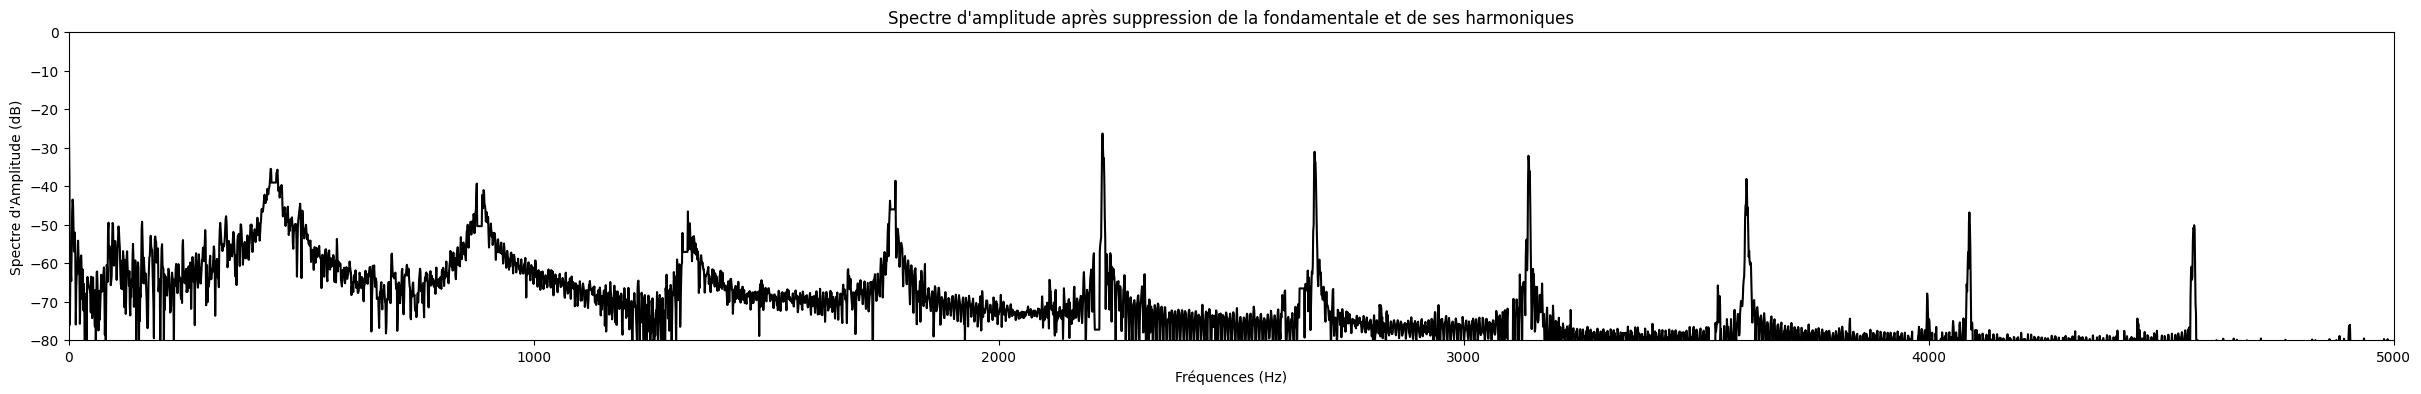

In [28]:
x_res = suppress_harmonics(X_fft,fond_freq,df,alpha)

plt.figure(figsize=(30, 4))
plt.plot(frequencies[:int(Nfft/2)], 20*np.log10(x_res[:int(Nfft/2)]), color='k') 
plt.xlim(0, 5000)
plt.ylim(-80, 0)
plt.xlabel('Fréquences (Hz)')
plt.ylabel("Spectre d'Amplitude (dB)")
plt.title("Spectre d'amplitude après suppression de la fondamentale et de ses harmoniques")
plt.show()


After the suppression of all the harmonics, we repeat the procedure (spectral sum, then detection of the fundamental frequency). We stop when there are no more large peaks in the spectrum. For example, when the largest remaining peak is less than 10% of the initial largest peak (we will put it as an argument of our algorithm in order to be flexible). 

In [29]:
def multipitch_detect(
    x_fft, 
    df,
    Fmin, 
    Fmax,
    H=4, 
    method='sum',
    alpha=0.005,
    beta=0.0,
    Kmax=30,
    stop_ratio=0.1,
    max_pitches=8,
    plot = False
):
    """
    Multi-pitch detection 


    Returns
    -------
    pitches_hz : list[float]
        Detected fundamental frequencies.

    """
    x_res = x_fft.copy()  
    Rmax = int(np.floor(len(x_res) / H))

    Nmin = f2idx(Fmin,df)-1
    Nmax = f2idx(Fmax,df)

    pitches_hz = []

    peak0 = None
    
    if plot: 
            plt.figure(figsize=(30, 4))
            plt.plot(frequencies[:int(Nfft/2)], 20*np.log10(x_res[:int(Nfft/2)]), color='k') 
            plt.xlim(0, 5000)
            plt.ylim(-80, 0)
            plt.xlabel('Fréquences (Hz)')
            plt.ylabel("Spectre d'Amplitude (dB)")
            plt.title("Spectre d'amplitude original")
            plt.show()


    for it in range(max_pitches):
        
        P = spectral_method(x_res, Rmax, H, method=method)

        idx0 = int(np.argmax(P[Nmin:Nmax+1]) + Nmin)
        
        f0 = idx0 * df
        best = float(P[idx0])

        if peak0 is None:
            peak0 = best

        # stopping criterion
        if best < stop_ratio * peak0:
            break

        pitches_hz.append(f0)

        # suppress this pitch (fundamental + harmonics)
        x_res = suppress_harmonics(
            x_res, fond_freq=f0, df=df,
            alpha=alpha, beta=beta, Kmax=Kmax
        )
        
        if plot: 
            plt.figure(figsize=(30, 4))
            plt.plot(frequencies[:int(Nfft/2)], 20*np.log10(x_res[:int(Nfft/2)]), color='k') 
            plt.xlim(0, 5000)
            plt.ylim(-80, 0)
            plt.xlabel('Fréquences (Hz)')
            plt.ylabel("Spectre d'Amplitude (dB)")
            plt.title("Spectre d'amplitude après une suppression")
            plt.show()

    return pitches_hz,x_res


## Fast testing on any sound

In [30]:
filename = 'A3C4E4G4_piano.wav' #A3_piano A3A4_piano A3A4A5_duo A3C4E4G4_piano A4_piano A5_flute Accord_trio C4F#4_Oboe_16 E4_oboe



music = os.path.join(data_path, filename)
wavefile = load_music(music)

Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

N=ceil(0.7*Fs)       # Window size of analysed signal (only one window of signal is analysed)
dF_min=Fs/N   # Minimal frequency resolution
print('The minimal frequency resolution is of {:.2f} Hz'.format(dF_min))

w=np.hamming(N)  # Window
width = 4*dF_min # largeur du pic spectral (en Hz) 4*dF_min
eps=float(1e-20)   #precision

offset=ceil(0.1*Fs)
xw=x[offset:offset+N]*w   # xw is the analysed signal frame
n_xw = xw.size


#Minimal number of data points to satisfy the minimal frequency resolution
Nfft_min=Fs/dF_min

#compute the smallest power of two that satisfies the minimal frequency resolution for FFT
p, Nfft = nextpow2(Nfft_min)
x_fft = np.fft.fft(xw, n=Nfft) #calcul FFT
x_fft /= np.max(np.abs(x_fft))+eps # Normalization

df=Fs/Nfft # frequency virtual resolution of FFT
print('Frequency virtual resolution of FFT {:.2} Hz'.format(df))

frequencies = np.arange(Nfft)*df  # equivalent to np.fft.fftfreq(n=Nfft, d=timestep)
X_fft = np.abs(x_fft) # absolute value of FFT (phase doesn't play a role)

The minimal frequency resolution is of 1.43 Hz
Frequency virtual resolution of FFT 0.98 Hz


In [31]:
Fmin=100             # Minimal F0 frequency that can be detected
Fmax=900             # Maximal F0 frequency that can be detected
H=4                  # H = nombre de versions compressées
Rmax = floor(Nfft/(2*H)) # fréquence maximale

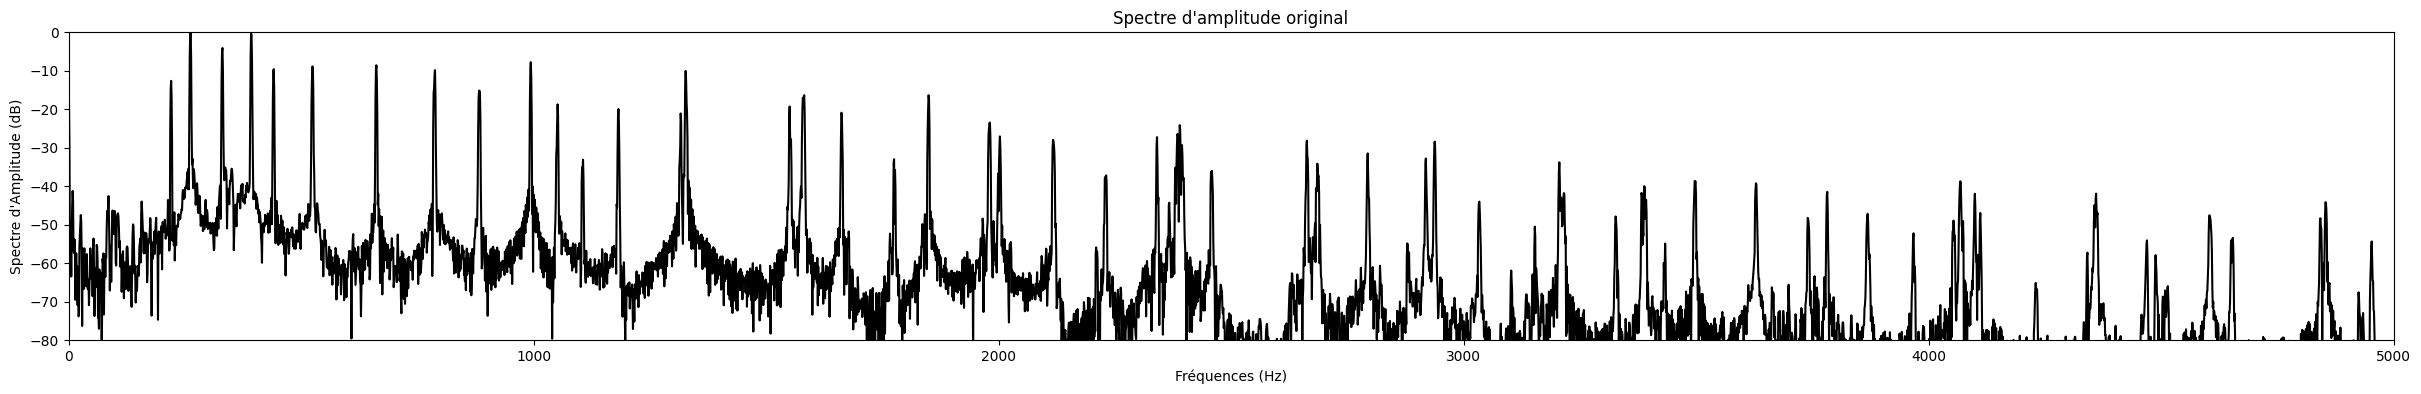

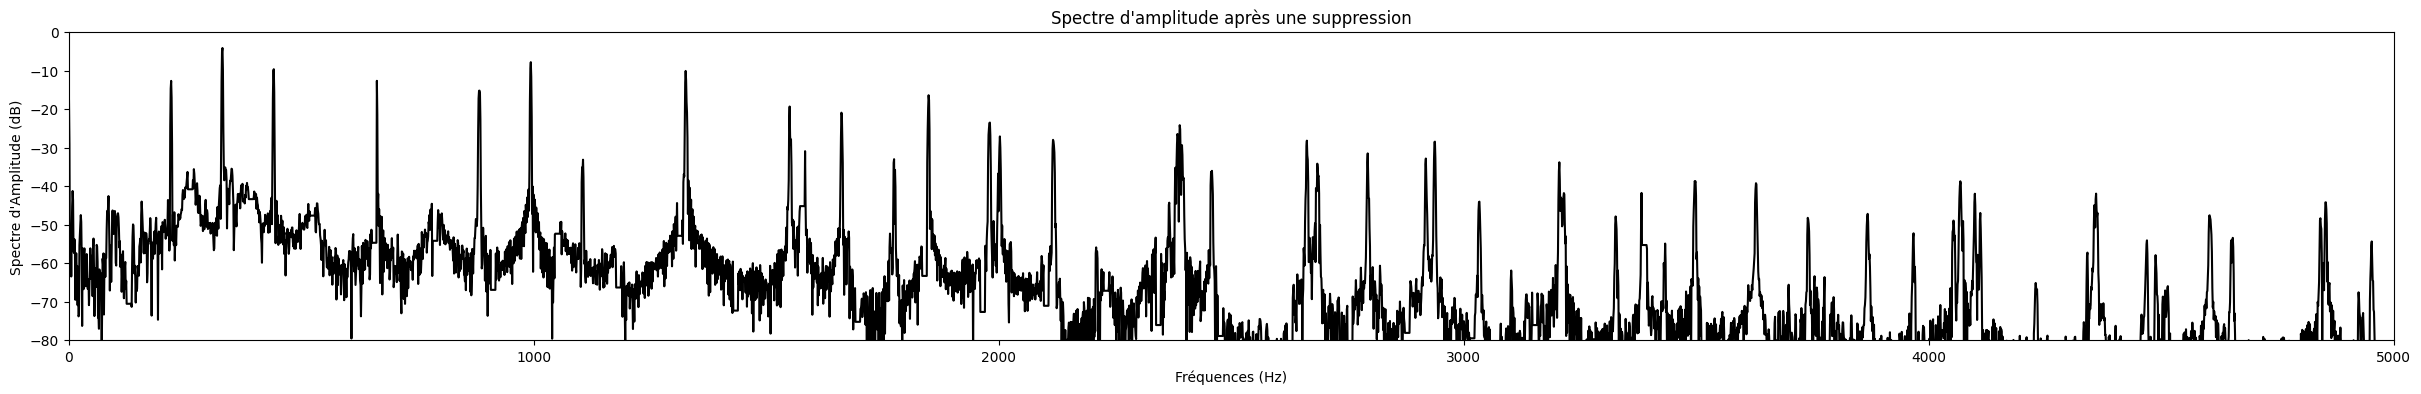

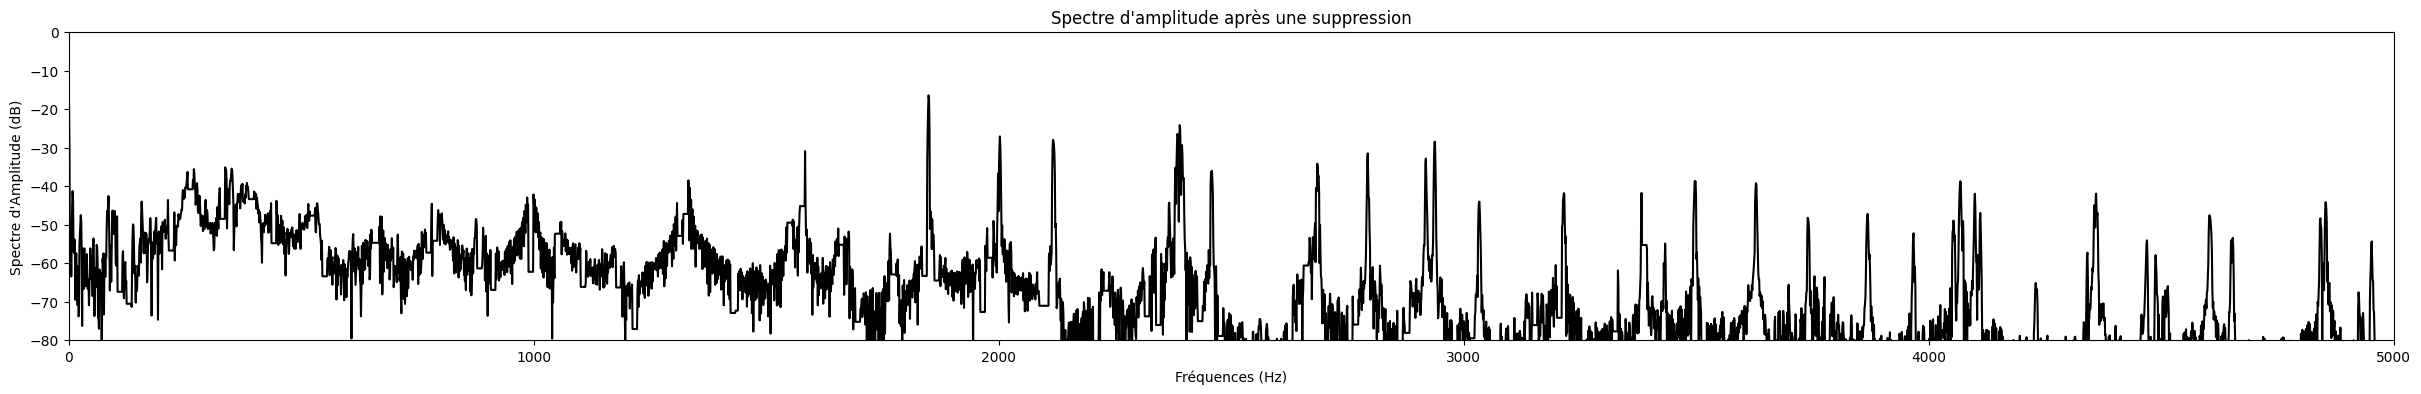

[130.859375, 110.3515625]

In [32]:
pitches_hz,x_res = multipitch_detect(X_fft, df, Fmin, Fmax, plot = True)
pitches_hz

| Signal file                       | Expected notes               | Detected notes |
| --------------------------------- | ---------------------------- | -------------- |
| **A3_piano.wav**                  | A3 (220 Hz)                  |    [220.703125]            |
| **A3A4_piano.wav**                | A3 (220), A4 (440)           |    [220.703125]            |
| **A3A4A5_duo.wav**                | A3 (220), A4 (440), A5 (880) |    [888.671875, 220.703125]            |
| **A3C4E4G4_piano.wav**            | A3 (220), C4 (262), E4 (330), G4 (392)             |       [130.859375, 110.3515625]         |
| **A4_piano.wav**                  | A4 (440 Hz)                  |       [441.40625]         |
| **A5_flute.wav**                  | A5 (880 Hz)                  |    [888.671875]            |
| **Accord_trio.wav** | ???     |      [330.078125, 888.671875, 130.859375, 220.703125]          |
| **C4F#4_Oboe_16.wav** | C4 (261.6), F#4 (369.9)      |       [371.09375, 653.3203125, 261.71875]         |
| **E4_oboe.wav**                   | E4 (329.63 Hz)               |     [330.078125]           |



# IV - some refinement or options
### Let's try with the product 

In [33]:
pitches_hz,x_res = multipitch_detect(X_fft, df, Fmin, Fmax,method='product')
pitches_hz

[262.6953125, 220.703125]

In [34]:
method = 'sum'
P = spectral_method(X_fft, Rmax, H, method)

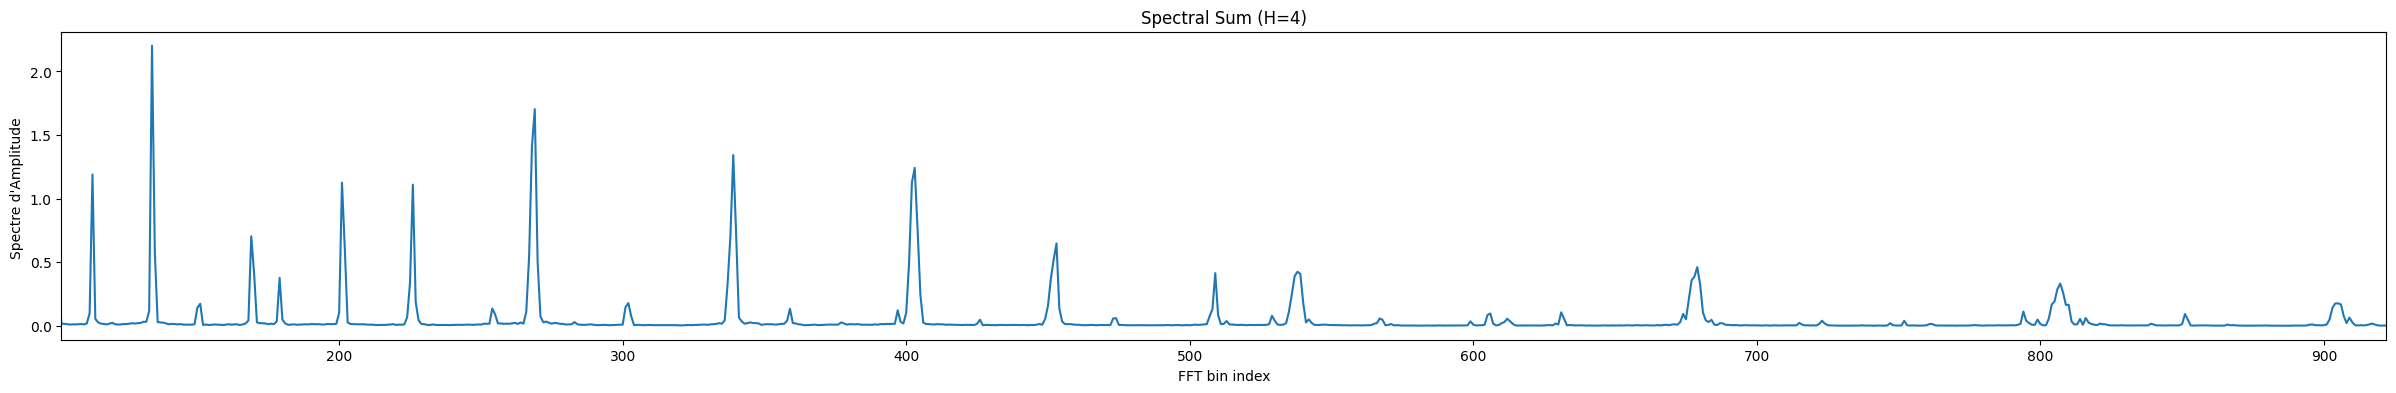

In [35]:
# with bins
plt.figure(figsize=(30, 4))
plt.plot(P)
plt.xlim(Nmin, Nmax)
plt.xlabel('FFT bin index')
plt.ylabel('Spectre d\'Amplitude ')
plt.title(f'Spectral Sum (H={H})')
plt.show()

In [36]:
method = 'product'
P = spectral_method(X_fft, Rmax, H, method)

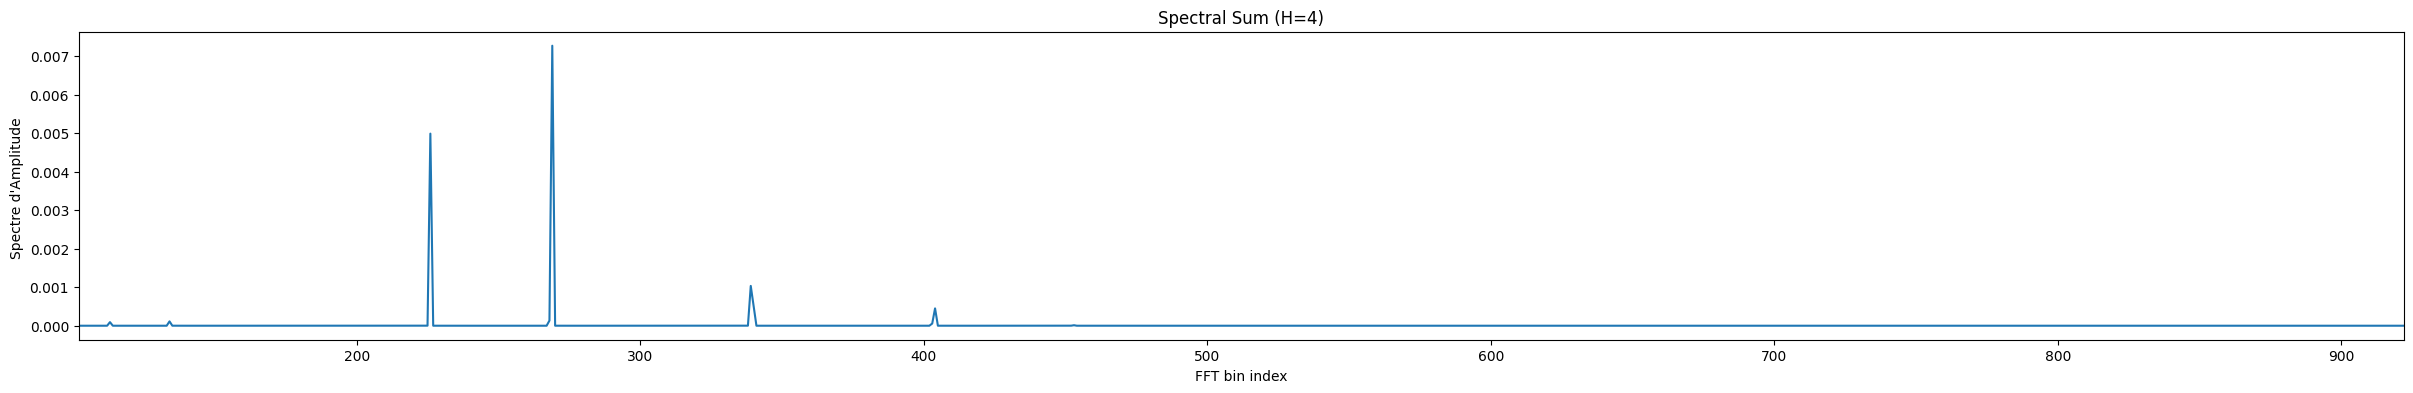

In [37]:
# with bins
plt.figure(figsize=(30, 4))
plt.plot(P)
plt.xlim(Nmin, Nmax)
plt.xlabel('FFT bin index')
plt.ylabel('Spectre d\'Amplitude ')
plt.title(f'Spectral Sum (H={H})')
plt.show()

We can see that with the product, the spectral estimation is easier: we get fewer peaks.

| Signal file                       | Expected notes               | Detected notes (sum) |Detected notes (prod) | Detected notes (prod) |
| --------------------------------- | ---------------------------- | -------------- |-------------- |-------------- |
| **A3_piano.wav**                  | A3 (220 Hz)                  |    [220.703125]            | [220.703125]            |  ok for both | 
| **A3A4_piano.wav**                | A3 (220), A4 (440)           |    [220.703125]            |[220.703125]            |  not ok but difficult | 
| **A3A4A5_duo.wav**                | A3 (220), A4 (440), A5 (880) |    [888.671875, 220.703125]            | [887.6953125]  |  not ok but difficult  | 
| **A3C4E4G4_piano.wav**            | A3 (220), C4 (262), E4 (330), G4 (392)            |       [130.859375, 110.3515625]         | [262.6953125, 220.703125]  |  product is better   | 
| **A4_piano.wav**                  | A4 (440 Hz)                  |       [441.40625]         |[441.40625]         | ok for both  | 
| **A5_flute.wav**                  | A5 (880 Hz)                  |    [888.671875]            |  [887.6953125]           | ok for both  | 
| **Accord_trio.wav** | ???     |      [330.078125, 888.671875, 130.859375, 220.703125]          | [330.078125]  | sum is better? |
| **C4F#4_Oboe_16.wav** | C4 (261.6), F#4 (369.9)      |       [371.09375, 653.3203125, 261.71875]         |  [371.09375, 261.71875]| product is better |
| **E4_oboe.wav**                   | E4 (329.63 Hz)               |     [330.078125]           |  [330.078125]           | ok for both  | 

 

### Taking into account the inharmonicity

In theory, we could estimate $\beta$ automatically by detecting the harmonics and estimating the coefficient, but in practice it is difficult because the signals are noisy and harmonic detection may not be precise enough. $\beta$ seems to be small, we will use $\beta = 0.001$ for the piano.  


In [38]:
pitches_hz,x_res = multipitch_detect(X_fft, df, Fmin, Fmax,method='product', beta=0.001)
pitches_hz

[262.6953125, 220.703125]

| Signal file            | Expected notes                            | Detected notes (sum)                             | Detected notes (prod)     |Detected notes (sum + beta = 0.001)            | Detected notes (prod + beta = 0.001)  | 
| ---------------------- | ----------------------------------------- | ------------------------------------------------ | ------------------------- | -------------------- | -------------------- |
| **A3_piano.wav**       | A3 (220 Hz)                               | [220.703125]                                     | [220.703125]              | [220.703125, 443.359375, 387.6953125]      | [220.703125]   
| **A3A4_piano.wav**     | A3 (220), A4 (440)                        | [220.703125]                                     | [220.703125]              | [220.703125, 663.0859375] | [220.703125] | 
| **A3C4E4G4_piano.wav** | A3 (220), C4 (262), E4 (330), G4 (392) | [130.859375, 110.3515625]                        | [262.6953125, 220.703125] | [130.859375, 110.3515625, 442.3828125, 497.0703125, 526.3671875]   | [262.6953125, 220.703125] | 
| **A4_piano.wav**       | A4 (440 Hz)                               | [441.40625]                                      | [441.40625]               | [441.40625]        | [441.40625]        |


It looks like our value of $\beta$ might be too large, and harmonics are not being suppressed efficiently, especially with the sum method.